In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nicksri1248/ushape-dataset/ushape.csv", header=None, names=['X', 'Y', 'class'])

In [3]:
df['X'] = df['X'].round(4)
df['Y'] = df['Y'].round(4)

In [4]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1151,-0.0462,1.0
2,0.8825,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8295,-0.5393,1.0


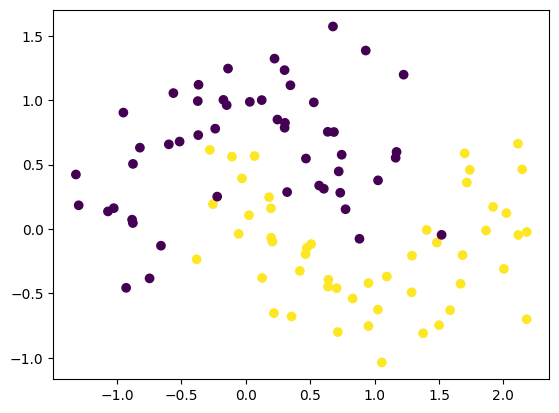

In [5]:
plt.scatter(df['X'], df['Y'], c = df['class'])

In [6]:
X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

2026-06-08 17:56:11.890182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780941372.089026      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780941372.140023      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780941372.620787      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780941372.620843      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780941372.620845      58 computation_placer.cc:177] computation placer alr

# Zero Initialization 

## ReLU

In [8]:
model = Sequential()

model.add(Dense(2, activation = 'relu', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-08 17:56:26.248399: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Set parameters to 0
model.get_weights()

[array([[-0.93788016, -0.88393515],
        [ 0.21477914,  0.23243594]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.1485411 ],
        [ 0.02490032]], dtype=float32),
 array([0.], dtype=float32)]

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [12]:
model.set_weights(initial_weights)

In [13]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [14]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [15]:
history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [16]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([-0.00483292], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 807us/step


<Axes: >

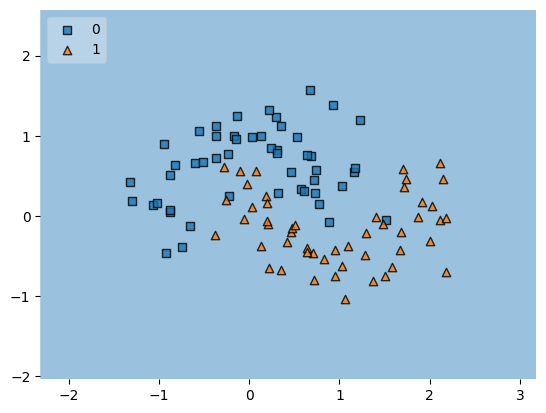

In [17]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

## TanH

In [18]:
model = Sequential()

model.add(Dense(2, activation = 'tanh', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Set parameters to 0
model.get_weights()

[array([[-0.35676712, -0.46494216],
        [ 0.6054144 ,  0.39785326]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.56961197],
        [-1.1356711 ]], dtype=float32),
 array([0.], dtype=float32)]

In [20]:
initial_weights = model.get_weights()

In [21]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [22]:
model.set_weights(initial_weights)

In [23]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [24]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [25]:
history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [26]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.00171701], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 795us/step


<Axes: >

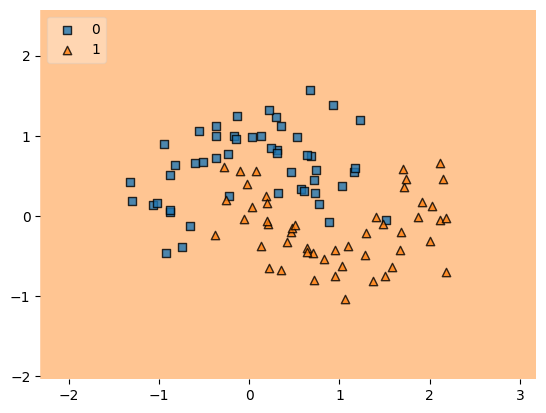

In [27]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

## Sigmoid

In [28]:
model = Sequential()

model.add(Dense(2, activation = 'sigmoid', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Set parameters to 0
model.get_weights()

[array([[-0.56761265, -0.1626612 ],
        [-0.4593354 ,  0.64788866]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.3118081],
        [0.8966037]], dtype=float32),
 array([0.], dtype=float32)]

In [30]:
initial_weights = model.get_weights()

In [31]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [32]:
model.set_weights(initial_weights)

In [33]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [34]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [35]:
history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.4500 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [36]:
model.get_weights()

[array([[ 0.4780667 ,  0.4780667 ],
        [-0.50800234, -0.50800234]], dtype=float32),
 array([-0.06891743, -0.06891743], dtype=float32),
 array([[0.11064132],
        [0.11064132]], dtype=float32),
 array([-0.0210894], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 784us/step


<Axes: >

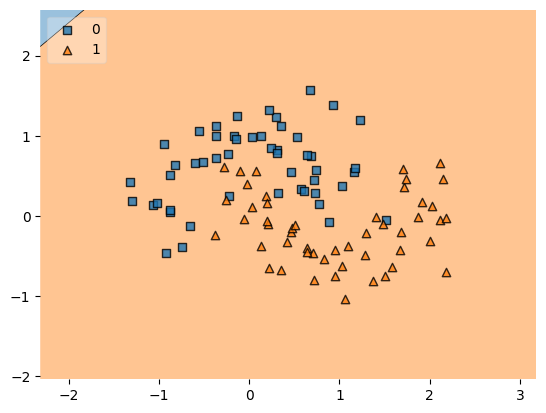

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

In [38]:
model = Sequential()

model.add(Dense(10, activation = 'sigmoid', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Set parameters to 0
model.get_weights()

[array([[ 0.12113392, -0.30077273,  0.01635396,  0.33554   ,  0.26341444,
          0.56237584, -0.05220711, -0.48791063, -0.55061823,  0.67579335],
        [ 0.3821805 ,  0.29840654,  0.5309616 , -0.23762342,  0.26383555,
          0.08757591, -0.43341678,  0.40613574,  0.5081493 , -0.00472581]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.68964255],
        [ 0.3118785 ],
        [-0.5372263 ],
        [ 0.13426685],
        [ 0.7130688 ],
        [ 0.60269254],
        [ 0.10956198],
        [ 0.1399005 ],
        [ 0.7338452 ],
        [-0.4829936 ]], dtype=float32),
 array([0.], dtype=float32)]

In [40]:
initial_weights = model.get_weights()

initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

model.set_weights(initial_weights)

model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [41]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.4500 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss:

In [42]:
model.get_weights()

[array([[ 0.47412556,  0.47412556,  0.47412556,  0.47412556,  0.47412556,
          0.47412556,  0.47412556,  0.47412556,  0.47412556,  0.47412556],
        [-0.49953064, -0.49953064, -0.49953064, -0.49953064, -0.49953064,
         -0.49953064, -0.49953064, -0.49953064, -0.49953064, -0.49953064]],
       dtype=float32),
 array([-0.16412756, -0.16412756, -0.16412756, -0.16412756, -0.16412756,
        -0.16412756, -0.16412756, -0.16412756, -0.16412756, -0.16412756],
       dtype=float32),
 array([[0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259],
        [0.06386259]], dtype=float32),
 array([-0.07569282], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 784us/step


<Axes: >

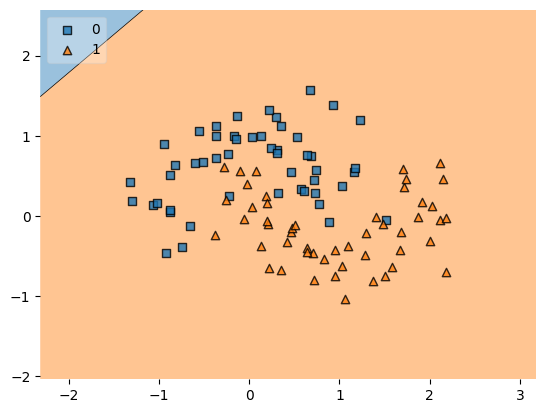

In [43]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

# Same constant value initialization

## ReLU

In [44]:
model = Sequential()

model.add(Dense(2, activation = 'relu', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Set parameters to 0
model.get_weights()

[array([[ 0.43651462, -0.2501884 ],
        [-0.43368042, -0.51493317]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.97297204],
        [-1.2108091 ]], dtype=float32),
 array([0.], dtype=float32)]

In [46]:
initial_weights = model.get_weights()

initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

model.set_weights(initial_weights)

model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [47]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5000 - loss: 0.9312 - val_accuracy: 0.5000 - val_loss: 0.8206
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.9273 - val_accuracy: 0.5000 - val_loss: 0.8178
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.9229 - val_accuracy: 0.5000 - val_loss: 0.8149
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.9189 - val_accuracy: 0.5000 - val_loss: 0.8121
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.9147 - val_accuracy: 0.5000 - val_loss: 0.8093
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.9110 - val_accuracy: 0.5000 - val_loss: 0.8065
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.9069 - val_accuracy: 0.5000 - val_loss: 0.8038
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.9031 - val_accuracy: 0.5000 - val_loss:

In [48]:
model.get_weights()

[array([[0.5297242 , 0.5297242 ],
        [0.25236923, 0.25236923]], dtype=float32),
 array([0.3028066, 0.3028066], dtype=float32),
 array([[0.29207283],
        [0.29207283]], dtype=float32),
 array([0.25421295], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 859us/step


<Axes: >

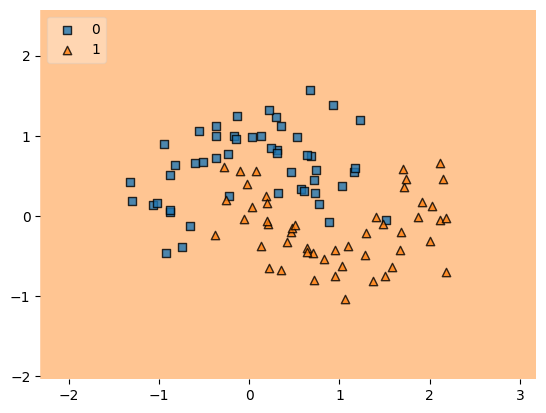

In [49]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

## TanH

In [50]:
model = Sequential()

model.add(Dense(2, activation = 'tanh', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Set parameters to 0
model.get_weights()

[array([[ 0.9359251 , -0.4228927 ],
        [-1.1565922 ,  0.53892994]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.46328825],
        [-0.31020856]], dtype=float32),
 array([0.], dtype=float32)]

In [52]:
initial_weights = model.get_weights()

initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

model.set_weights(initial_weights)

model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [53]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5000 - loss: 0.8523 - val_accuracy: 0.5000 - val_loss: 0.7755
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.8497 - val_accuracy: 0.5000 - val_loss: 0.7730
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.8472 - val_accuracy: 0.5000 - val_loss: 0.7704
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.8446 - val_accuracy: 0.5000 - val_loss: 0.7679
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.8420 - val_accuracy: 0.5000 - val_loss: 0.7654
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.8395 - val_accuracy: 0.5000 - val_loss: 0.7630
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.8371 - val_accuracy: 0.5000 - val_loss: 0.7606
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5000 - loss: 0.8348 - val_accuracy: 0.5000 - val_loss:

In [54]:
model.get_weights()

[array([[0.72018135, 0.72018135],
        [0.22556508, 0.22556508]], dtype=float32),
 array([0.26283562, 0.26283562], dtype=float32),
 array([[0.30051222],
        [0.30051222]], dtype=float32),
 array([0.25642097], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 840us/step


<Axes: >

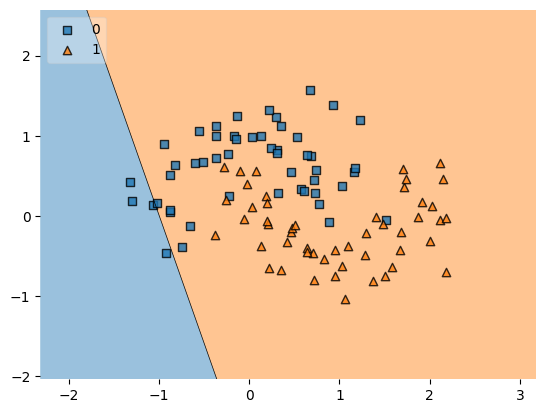

In [55]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

## Sigmoid

In [56]:
model = Sequential()

model.add(Dense(2, activation = 'sigmoid', input_dim = 2))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Set parameters to 0
model.get_weights()

[array([[ 1.1969293 , -1.2178212 ],
        [-0.65042734,  1.0141515 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 1.3732921 ],
        [-0.92536604]], dtype=float32),
 array([0.], dtype=float32)]

In [58]:
initial_weights = model.get_weights()

initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

model.set_weights(initial_weights)

model.get_weights()

[array([[0.5, 0.5],
        [0.5, 0.5]], dtype=float32),
 array([0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [59]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5000 - loss: 0.8636 - val_accuracy: 0.5000 - val_loss: 0.8362
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.8612 - val_accuracy: 0.5000 - val_loss: 0.8342
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.8593 - val_accuracy: 0.5000 - val_loss: 0.8322
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.8570 - val_accuracy: 0.5000 - val_loss: 0.8302
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.8551 - val_accuracy: 0.5000 - val_loss: 0.8283
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.8531 - val_accuracy: 0.5000 - val_loss: 0.8263
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5000 - loss: 0.8509 - val_accuracy: 0.5000 - val_loss: 0.8244
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5000 - loss: 0.8490 - val_accuracy: 0.5000 - val_loss:

In [60]:
model.get_weights()

[array([[0.71563864, 0.71563864],
        [0.24708828, 0.24708828]], dtype=float32),
 array([0.27449474, 0.27449474], dtype=float32),
 array([[0.2672273],
        [0.2672273]], dtype=float32),
 array([0.25253546], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 890us/step


<Axes: >

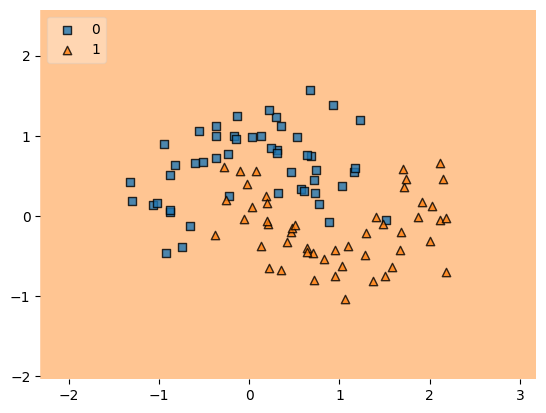

In [61]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)

# Random Initialization

In [62]:
model = Sequential()

model.add(Dense(2, activation = 'tanh', input_dim = 2))
model.add(Dense(2, activation = 'tanh'))
model.add(Dense(2, activation = 'tanh'))
model.add(Dense(2, activation = 'tanh'))
model.add(Dense(1, activation = 'sigmoid'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.get_weights()

[array([[-1.2187159, -1.1390064],
        [-0.9723954, -0.8285389]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.39333975, -0.5964759 ],
        [ 0.36165082, -0.93643653]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.18829596,  0.7903906 ],
        [ 0.47256744, -0.4509161 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.04970515, 0.67054045],
        [0.73716795, 0.2865275 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.2905358 ],
        [ 0.74830925]], dtype=float32),
 array([0.], dtype=float32)]

In [64]:
initial_weights = model.get_weights()

In [65]:
initial_weights[0] = np.random.randn(model.get_weights()[0].shape[0], model.get_weights()[0].shape[1])
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(model.get_weights()[2].shape[0], model.get_weights()[2].shape[1])
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(model.get_weights()[4].shape[0], model.get_weights()[4].shape[1])
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(model.get_weights()[6].shape[0], model.get_weights()[6].shape[1])
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(model.get_weights()[8].shape[0], model.get_weights()[8].shape[1])
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [66]:
model.set_weights(initial_weights)

In [67]:
model.get_weights()

[array([[-0.48483273, -0.50170106],
        [-0.163549  , -0.01450079]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.41273412,  0.5168576 ],
        [ 0.03701025, -0.02930093]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-5.3686225e-01,  5.0382933e-04],
        [-1.2950023e+00, -9.1336089e-01]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.23141879,  1.1150527 ],
        [-0.34219995,  0.4744958 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-1.4777218],
        [-1.1029428]], dtype=float32),
 array([0.], dtype=float32)]

In [68]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

history = model.fit(X, y, epochs = 100, validation_split = 0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.4125 - loss: 0.7303 - val_accuracy: 0.2500 - val_loss: 0.7683
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4000 - loss: 0.7269 - val_accuracy: 0.2500 - val_loss: 0.7639
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3875 - loss: 0.7249 - val_accuracy: 0.3000 - val_loss: 0.7596
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4000 - loss: 0.7219 - val_accuracy: 0.3000 - val_loss: 0.7556
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4250 - loss: 0.7197 - val_accuracy: 0.3500 - val_loss: 0.7515
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4375 - loss: 0.7174 - val_accuracy: 0.3500 - val_loss: 0.7476
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4375 - loss: 0.7152 - val_accuracy: 0.3500 - val_loss: 0.7438
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4625 - loss: 0.7132 - val_accuracy: 0.3500 - val_loss:

In [69]:
model.get_weights()

[array([[-0.24748735, -0.7122364 ],
        [-0.4070006 ,  0.41940075]], dtype=float32),
 array([0.02413551, 0.19890746], dtype=float32),
 array([[-0.4296997 ,  0.47623482],
        [-0.26803625, -0.33391392]], dtype=float32),
 array([-0.00506144,  0.01594269], dtype=float32),
 array([[-0.7215601 ,  0.15116647],
        [-1.4637582 , -0.98434275]], dtype=float32),
 array([-0.00768855, -0.01528228], dtype=float32),
 array([[ 0.49365267,  1.3716176 ],
        [-0.21443191,  0.59570634]], dtype=float32),
 array([-0.0085189 , -0.01108499], dtype=float32),
 array([[-1.7495308],
        [-1.3412001]], dtype=float32),
 array([0.00979304], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

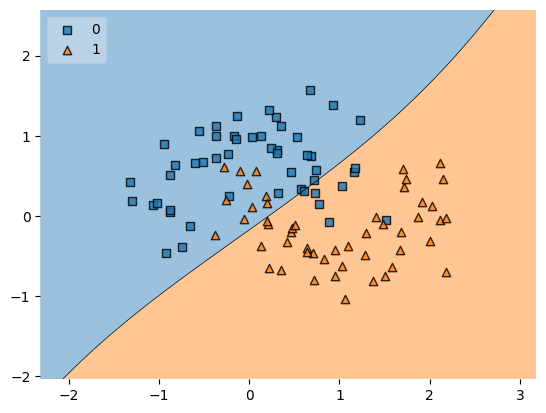

In [70]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf = model, legend = 2)